# Xây dựng Mô hình Phân loại và Dự báo Rủi ro Khách hàng Vay vốn

**Notebook 03/07 - Data Cleaning (Làm sạch dữ liệu)**

---

**Mục tiêu:** Làm sạch từng bảng trong PostgreSQL, tổng hợp và Join lại thành dữ liệu sạch phục vụ EDA.

**Input:** 8 bảng raw trong PostgreSQL được nạp ở Notebook 02.

**Output:** Các bảng clean, các bảng clean summary và bảng `application_flat_cleaned`.

**Pipeline:** Notebook 02 - Database Organization -> **Notebook 03 - Data Cleaning** -> Notebook 04 - EDA

## 1. Giới thiệu

### 1.1. Mục tiêu và phạm vi

Notebook này làm sạch dữ liệu **trước khi tổng hợp và Join**, thay vì chỉ xử lý bảng `application_flat` đã được tạo ở Notebook 02. Cách làm này giúp phát hiện lỗi ở cấp bản ghi của từng bảng và tránh để dữ liệu sai ảnh hưởng đến các chỉ số tổng hợp.

Phạm vi gồm 8 bảng raw trong PostgreSQL: `application_train`, `application_test`, `bureau`, `bureau_balance`, `previous_application`, `installments_payments`, `pos_cash_balance` và `credit_card_balance`. Mỗi bảng được kiểm tra Missing, Duplicate, Outlier, sai logic, Data Type và các cột không cần thiết.

Sau khi cleaning, các bảng phụ được tổng hợp về mức khách hàng rồi Join với `application_train_cleaned` để tạo `application_flat_cleaned`. Bảng `application_test` được làm sạch bằng cùng nguyên tắc và lưu riêng. Các bảng raw không bị ghi đè để luôn có dữ liệu gốc đối chiếu.

### 1.2. Data Cleaning Pipeline

Pipeline của Notebook 03 được thực hiện theo thứ tự sau:

```text
8 bảng raw trong PostgreSQL
        ↓
Quality Assessment
        ↓
Missing → Duplicate → Outlier → Logic Validation → Data Type
        ↓
Các bảng clean
        ↓
Tổng hợp bảng phụ → Kiểm tra khóa → LEFT JOIN
        ↓
Xử lý Missing phát sinh sau Join
        ↓
application_flat_cleaned → PostgreSQL → Notebook 04
```

PostgreSQL đảm nhận việc cleaning, tổng hợp và Join các bảng lớn để tránh tải hàng triệu dòng vào bộ nhớ. Python trong notebook dùng để kiểm tra chất lượng, trực quan hóa và giải thích kết quả.

## 2. Đọc dữ liệu từ PostgreSQL

### 2.1. Kết nối PostgreSQL và xác nhận 8 bảng raw

Đoạn code bên dưới khai báo các thư viện và xác định thư mục gốc của dự án.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psycopg2
from psycopg2 import sql
from dotenv import load_dotenv
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

Đoạn code bên dưới đọc cấu hình từ `.env` và kết nối tới PostgreSQL.

In [2]:
load_dotenv(PROJECT_ROOT / ".env", override=True)

required_keys = ["DB_HOST", "DB_PORT", "DB_NAME", "DB_USER", "DB_PASSWORD"]
missing_keys = [key for key in required_keys if not os.getenv(key)]
if missing_keys:
    raise EnvironmentError(f"Thiếu cấu hình trong .env: {', '.join(missing_keys)}")

conn = psycopg2.connect(
    host=os.getenv("DB_HOST"), port=os.getenv("DB_PORT"),
    dbname=os.getenv("DB_NAME"), user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
)
print(f"Đã kết nối database: {os.getenv('DB_NAME')}")

Đã kết nối database: credit_risk_db


Đoạn code bên dưới kiểm tra 8 bảng raw cần dùng cho toàn bộ quá trình cleaning.

In [3]:
raw_tables = [
    "application_train", "application_test", "bureau", "bureau_balance",
    "previous_application", "installments_payments",
    "pos_cash_balance", "credit_card_balance",
]

with conn.cursor() as cursor:
    cursor.execute(
        "SELECT table_name FROM information_schema.tables WHERE table_schema = 'public' AND table_name = ANY(%s)",
        (raw_tables,),
    )
    found_tables = {row[0] for row in cursor.fetchall()}

table_status = pd.DataFrame({
    "Tên bảng": raw_tables,
    "Trạng thái": ["Sẵn sàng" if table in found_tables else "Thiếu" for table in raw_tables],
})
assert len(found_tables) == len(raw_tables), "PostgreSQL chưa có đủ 8 bảng raw"
display(table_status)

,Tên bảng,Trạng thái
0,application_train,Sẵn sàng
1,application_test,Sẵn sàng
2,bureau,Sẵn sàng
3,bureau_balance,Sẵn sàng
4,previous_application,Sẵn sàng
5,installments_payments,Sẵn sàng
6,pos_cash_balance,Sẵn sàng
7,credit_card_balance,Sẵn sàng


**Nhận xét:** PostgreSQL có đủ 8 bảng raw cần thiết. Notebook có thể tiếp tục khảo sát chất lượng và cleaning từng bảng mà không cần đọc lại các file CSV.

### 2.2. Khảo sát tổng quan từng bảng

Đoạn code bên dưới thống kê số dòng, số cột và dung lượng của 8 bảng trực tiếp trong PostgreSQL.

In [4]:
table_roles = {
    "application_train": "Bảng chính - train",
    "application_test": "Bảng chính - test",
    "bureau": "Lịch sử tín dụng",
    "bureau_balance": "Lịch sử tín dụng theo tháng",
    "previous_application": "Hồ sơ vay trước",
    "installments_payments": "Giao dịch trả góp",
    "pos_cash_balance": "Dư nợ POS/Cash theo tháng",
    "credit_card_balance": "Dư nợ thẻ theo tháng",
}

overview_rows = []
with conn.cursor() as cursor:
    for table in raw_tables:
        cursor.execute(sql.SQL("SELECT COUNT(*) FROM {}").format(sql.Identifier(table)))
        row_count = cursor.fetchone()[0]
        cursor.execute("SELECT COUNT(*) FROM information_schema.columns WHERE table_schema = 'public' AND table_name = %s", (table,))
        column_count = cursor.fetchone()[0]
        cursor.execute("SELECT pg_total_relation_size(%s::regclass)", (f"public.{table}",))
        size_mb = cursor.fetchone()[0] / 1024**2
        overview_rows.append([table, row_count, column_count, size_mb, table_roles[table]])

table_overview = pd.DataFrame(overview_rows, columns=["Tên bảng", "Số dòng", "Số cột", "Dung lượng (MB)", "Vai trò"])
table_overview["Dung lượng (MB)"] = table_overview["Dung lượng (MB)"].round(2)
display(table_overview)

,Tên bảng,Số dòng,Số cột,Dung lượng (MB),Vai trò
0,application_train,307511,122,158.68,Bảng chính - train
1,application_test,48744,121,25.60,Bảng chính - test
2,bureau,1716428,17,275.39,Lịch sử tín dụng
3,bureau_balance,27299925,3,1346.02,Lịch sử tín dụng theo tháng
4,previous_application,1670214,37,452.31,Hồ sơ vay trước
5,installments_payments,13605401,8,1163.55,Giao dịch trả góp
6,pos_cash_balance,10001358,8,802.31,Dư nợ POS/Cash theo tháng
7,credit_card_balance,3840312,23,528.50,Dư nợ thẻ theo tháng


Đoạn code bên dưới lấy 5 dòng và một số cột tiêu biểu của mỗi bảng để tránh in toàn bộ dữ liệu quá rộng.

In [5]:
sample_columns = {
    "application_train": ["sk_id_curr", "target", "code_gender", "amt_income_total", "amt_credit"],
    "application_test": ["sk_id_curr", "code_gender", "amt_income_total", "amt_credit"],
    "bureau": ["sk_id_curr", "sk_id_bureau", "credit_active", "days_credit", "amt_credit_sum_debt"],
    "bureau_balance": ["sk_id_bureau", "months_balance", "status"],
    "previous_application": ["sk_id_curr", "sk_id_prev", "name_contract_status", "amt_application", "days_decision"],
    "installments_payments": ["sk_id_curr", "sk_id_prev", "num_instalment_number", "amt_instalment", "amt_payment"],
    "pos_cash_balance": ["sk_id_curr", "sk_id_prev", "months_balance", "name_contract_status", "sk_dpd"],
    "credit_card_balance": ["sk_id_curr", "sk_id_prev", "months_balance", "amt_balance", "sk_dpd"],
}

table_samples = {}
with conn.cursor() as cursor:
    for table, columns in sample_columns.items():
        query = sql.SQL("SELECT {} FROM {} LIMIT 5").format(
            sql.SQL(", ").join(map(sql.Identifier, columns)), sql.Identifier(table)
        )
        cursor.execute(query)
        table_samples[table] = pd.DataFrame(cursor.fetchall(), columns=columns)

In [6]:
for table in raw_tables:
    print(f"\n{table}")
    display(table_samples[table])


application_train


,sk_id_curr,target,code_gender,amt_income_total,amt_credit
0,100002,1,M,202500.0,406597.5
1,100003,0,F,270000.0,1293502.5
2,100004,0,M,67500.0,135000.0
3,100006,0,F,135000.0,312682.5
4,100007,0,M,121500.0,513000.0



application_test


,sk_id_curr,code_gender,amt_income_total,amt_credit
0,100001,F,135000.0,568800.0
1,100005,M,99000.0,222768.0
2,100013,M,202500.0,663264.0
3,100028,F,315000.0,1575000.0
4,100038,M,180000.0,625500.0



bureau


...

,sk_id_curr,sk_id_prev,num_instalment_number,amt_instalment,amt_payment
0,222998,1105542,48,9000.0,9000.0
1,287227,1185080,9,4900.23,4900.23
2,285309,1158183,3,8426.385,8426.385
3,225548,1354686,1,6945.3,6945.3
4,217454,1550316,33,13915.62,13.275



pos_cash_balance


,sk_id_curr,sk_id_prev,months_balance,name_contract_status,sk_dpd
0,182943,1803195,-31,Active,0
1,367990,1715348,-33,Active,0
2,397406,1784872,-32,Active,0
3,269225,1903291,-35,Active,0
4,334279,2341044,-35,Active,0



credit_card_balance


,sk_id_curr,sk_id_prev,months_balance,amt_balance,sk_dpd
0,298480,1411165,-42,83145.42,0
1,284236,1523890,-35,73528.155,0
2,174264,1639203,-42,33386.085,0
3,288585,2736759,-34,178375.455,0
4,250714,1854210,-35,136891.44,0


**Nhận xét:** `bureau_balance` lớn nhất với 27.299.925 dòng và khoảng 1.346,02 MB; tiếp theo là `installments_payments` với 13.605.401 dòng và `pos_cash_balance` với 10.001.358 dòng. `application_train` có nhiều cột nhất (122 cột). Vì vậy, các bảng giao dịch lớn sẽ được cleaning và tổng hợp trực tiếp trong PostgreSQL; Python chỉ nhận các bảng kết quả nhỏ để kiểm tra và trực quan hóa. Các mẫu 5 dòng cũng xác nhận mỗi bảng chứa đúng nhóm thông tin dự kiến mà không cần in toàn bộ hàng trăm cột.

### 2.3. Xác định grain và khóa của từng bảng

Mục này xác định một dòng của mỗi bảng đại diện cho điều gì và khóa nào phải dùng khi kiểm tra Duplicate hoặc Join. Nhờ đó, nhóm tránh xóa nhầm các dòng 1–N hợp lệ và tránh làm nhân bản khách hàng khi tạo bảng flat. Phần này chỉ kiểm tra cấu trúc, chưa thay đổi dữ liệu.

Đoạn code bên dưới ghi lại ý nghĩa của một dòng và khóa ứng viên của từng bảng.

In [7]:
grain_rules = {
    "application_train": (["sk_id_curr"], "Một khách hàng train", "Bảng trung tâm"),
    "application_test": (["sk_id_curr"], "Một khách hàng test", "Bảng trung tâm"),
    "bureau": (["sk_id_bureau"], "Một khoản tín dụng bên ngoài", "1 khách hàng - nhiều khoản"),
    "bureau_balance": (["sk_id_bureau", "months_balance"], "Một tháng của một khoản bureau", "1 khoản - nhiều tháng"),
    "previous_application": (["sk_id_prev"], "Một hồ sơ vay trước", "1 khách hàng - nhiều hồ sơ"),
    "installments_payments": (["sk_id_prev", "num_instalment_version", "num_instalment_number", "days_entry_payment"], "Một giao dịch trả góp", "1 hồ sơ - nhiều giao dịch"),
    "pos_cash_balance": (["sk_id_prev", "months_balance"], "Một tháng của khoản POS/Cash", "1 hồ sơ - nhiều tháng"),
    "credit_card_balance": (["sk_id_prev", "months_balance"], "Một tháng của thẻ tín dụng", "1 hồ sơ - nhiều tháng"),
}

grain_table = pd.DataFrame([
    [table, grain, " + ".join(keys), relation]
    for table, (keys, grain, relation) in grain_rules.items()
], columns=["Tên bảng", "Grain", "Khóa ứng viên", "Quan hệ"])
display(grain_table)

,Tên bảng,Grain,Khóa ứng viên,Quan hệ
0,application_train,Một khách hàng train,sk_id_curr,Bảng trung tâm
1,application_test,Một khách hàng test,sk_id_curr,Bảng trung tâm
2,bureau,Một khoản tín dụng bên ngoài,sk_id_bureau,1 khách hàng - nhiều khoản
3,bureau_balance,Một tháng của một khoản bureau,sk_id_bureau + months_balance,1 khoản - nhiều tháng
4,previous_application,Một hồ sơ vay trước,sk_id_prev,1 khách hàng - nhiều hồ sơ
5,installments_payments,Một giao dịch trả góp,sk_id_prev + num_instalment_version + num_inst...,1 hồ sơ - nhiều giao dịch
6,pos_cash_balance,Một tháng của khoản POS/Cash,sk_id_prev + months_balance,1 hồ sơ - nhiều tháng
7,credit_card_balance,Một tháng của thẻ tín dụng,sk_id_prev + months_balance,1 hồ sơ - nhiều tháng


**Nhận xét:** Các bảng chính có grain một khách hàng một dòng, còn các bảng phụ có quan hệ 1–N. Vì vậy không thể xem việc lặp lại SK_ID_CURR trong bảng phụ là Duplicate.

Đoạn code bên dưới kiểm tra chính xác khóa định danh của các bảng hồ sơ. Khóa ghép của bảng giao dịch sẽ được kiểm tra đầy đủ ở Mục 3.2 để tránh lặp lại phép quét dữ liệu lớn.

In [8]:
entity_keys = {
    "application_train": "sk_id_curr",
    "application_test": "sk_id_curr",
    "bureau": "sk_id_bureau",
    "previous_application": "sk_id_prev",
}

key_rows = []
with conn.cursor() as cursor:
    for table, key in entity_keys.items():
        query = sql.SQL(
            "SELECT COUNT(*), COUNT(DISTINCT {}), COUNT(*) FILTER (WHERE {} IS NULL) FROM {}"
        ).format(sql.Identifier(key), sql.Identifier(key), sql.Identifier(table))
        cursor.execute(query)
        total_rows, distinct_keys, null_keys = cursor.fetchone()
        key_rows.append([table, key, total_rows, distinct_keys, total_rows - distinct_keys, null_keys])

key_quality = pd.DataFrame(key_rows, columns=[
    "Tên bảng", "Khóa định danh", "Số dòng", "Số khóa khác nhau", "Dòng vượt grain", "Dòng thiếu khóa"
])
raw_key_baseline = key_quality.copy()
display(key_quality)

,Tên bảng,Khóa định danh,Số dòng,Số khóa khác nhau,Dòng vượt grain,Dòng thiếu khóa
0,application_train,sk_id_curr,307511,307511,0,0
1,application_test,sk_id_curr,48744,48744,0,0
2,bureau,sk_id_bureau,1716428,1716428,0,0
3,previous_application,sk_id_prev,1670214,1670214,0,0


Đoạn code bên dưới kiểm tra train và test không trùng khách hàng, sau đó đo số Foreign Key không tìm thấy bảng cha.

In [9]:
foreign_key_queries = {
    "bureau → application": "WITH app AS (SELECT sk_id_curr FROM application_train UNION SELECT sk_id_curr FROM application_test) SELECT COUNT(*), COUNT(*) FILTER (WHERE p.sk_id_curr IS NULL) FROM bureau c LEFT JOIN app p USING (sk_id_curr)",
    "bureau_balance → bureau": "SELECT COUNT(*), COUNT(*) FILTER (WHERE p.sk_id_bureau IS NULL) FROM bureau_balance c LEFT JOIN bureau p USING (sk_id_bureau)",
    "previous → application": "WITH app AS (SELECT sk_id_curr FROM application_train UNION SELECT sk_id_curr FROM application_test) SELECT COUNT(*), COUNT(*) FILTER (WHERE p.sk_id_curr IS NULL) FROM previous_application c LEFT JOIN app p USING (sk_id_curr)",
    "installments → previous": "SELECT COUNT(*), COUNT(*) FILTER (WHERE p.sk_id_prev IS NULL) FROM installments_payments c LEFT JOIN previous_application p USING (sk_id_prev)",
    "pos_cash → previous": "SELECT COUNT(*), COUNT(*) FILTER (WHERE p.sk_id_prev IS NULL) FROM pos_cash_balance c LEFT JOIN previous_application p USING (sk_id_prev)",
    "credit_card → previous": "SELECT COUNT(*), COUNT(*) FILTER (WHERE p.sk_id_prev IS NULL) FROM credit_card_balance c LEFT JOIN previous_application p USING (sk_id_prev)",
}

with conn.cursor() as cursor:
    cursor.execute("SELECT COUNT(*) FROM application_train t JOIN application_test x USING (sk_id_curr)")
    train_test_overlap = cursor.fetchone()[0]
    fk_rows = []
    for relation, query in foreign_key_queries.items():
        cursor.execute(query)
        total_rows, orphan_rows = cursor.fetchone()
        fk_rows.append([relation, total_rows, orphan_rows, orphan_rows / total_rows * 100])

assert train_test_overlap == 0, "application_train và application_test bị trùng khách hàng"
foreign_key_quality = pd.DataFrame(fk_rows, columns=["Quan hệ", "Số dòng con", "Không khớp bảng cha", "Tỷ lệ (%)"])
foreign_key_quality["Tỷ lệ (%)"] = foreign_key_quality["Tỷ lệ (%)"].round(4)
raw_fk_baseline = foreign_key_quality.copy()
print(f"Số khách hàng trùng giữa train và test: {train_test_overlap}")
display(foreign_key_quality)

Số khách hàng trùng giữa train và test: 0


,Quan hệ,Số dòng con,Không khớp bảng cha,Tỷ lệ (%)
0,bureau → application,1716428,0,0.0000
1,bureau_balance → bureau,27299925,3120184,11.4293
2,previous → application,1670214,0,0.0000
3,installments → previous,13605401,1250826,9.1936
4,pos_cash → previous,10001358,340561,3.4051
5,credit_card → previous,3840312,1082816,28.1960


**Nhận xét:** `application_train`, `application_test`, `bureau` và `previous_application` đều có khóa định danh duy nhất, không thiếu khóa và không có dòng vượt grain; train và test cũng không trùng khách hàng. `bureau` và `previous_application` khớp 100% với tập khách hàng train + test. Ngược lại, bốn quan hệ từ bảng giao dịch đến bảng cha có dòng không khớp: `bureau_balance` 11,4293%, `installments_payments` 9,1936%, `pos_cash_balance` 3,4051% và `credit_card_balance` 28,1960%. Điều này cho thấy các bảng raw của bộ Kaggle không khép kín hoàn toàn; nhóm giữ lại các số liệu này làm baseline và không tự động xóa bản ghi mồ côi. Khóa ghép của các bảng giao dịch sẽ được kiểm tra đầy đủ tại Mục 3.2.

## 3. Làm sạch dữ liệu

### 3.1. Xử lý Missing Values

**a. Kiểm tra Missing Values của từng bảng**

Đoạn code bên dưới đếm Missing trực tiếp trong PostgreSQL và lưu kết quả làm baseline trước cleaning.

In [10]:
missing_rows = []
missing_summary_rows = []

with conn.cursor() as cursor:
    for table in raw_tables:
        cursor.execute(
            "SELECT column_name, data_type FROM information_schema.columns "
            "WHERE table_schema = 'public' AND table_name = %s ORDER BY ordinal_position",
            (table,),
        )
        columns_info = cursor.fetchall()
        count_sql = sql.SQL(", ").join(
            sql.SQL("COUNT(*) - COUNT({})").format(sql.Identifier(column))
            for column, _ in columns_info
        )
        cursor.execute(
            sql.SQL("SELECT COUNT(*), {} FROM {}").format(count_sql, sql.Identifier(table))
        )
        result = cursor.fetchone()
        row_count, missing_counts = result[0], result[1:]
        for (column, data_type), missing_count in zip(columns_info, missing_counts):
            missing_rate = missing_count / row_count * 100
            missing_rows.append([table, column, data_type, missing_count, missing_rate])
        missing_summary_rows.append([
            table, row_count, len(columns_info),
            sum(count > 0 for count in missing_counts), sum(missing_counts),
        ])

missing_profile = pd.DataFrame(missing_rows, columns=[
    "Tên bảng", "Tên cột", "Data Type", "Số ô missing", "Tỷ lệ missing (%)"
])
missing_profile["Mức missing"] = "Không thiếu"
has_missing = missing_profile["Số ô missing"] > 0
missing_profile.loc[has_missing, "Mức missing"] = pd.cut(
    missing_profile.loc[has_missing, "Tỷ lệ missing (%)"],
    bins=[0, 5, 30, 100], labels=["<5%", "5–30%", ">30%"], include_lowest=True,
).astype(str)
raw_missing_baseline = missing_profile.copy()

Đoạn code bên dưới tổng hợp quy mô Missing và số cột thuộc từng mức của mỗi bảng.

In [11]:
missing_table_summary = pd.DataFrame(missing_summary_rows, columns=[
    "Tên bảng", "Số dòng", "Số cột", "Số cột có missing", "Tổng ô missing"
])
missing_level_summary = (missing_profile[has_missing]
    .groupby(["Tên bảng", "Mức missing"]).size().unstack(fill_value=0)
    .reindex(index=raw_tables, columns=["<5%", "5–30%", ">30%"], fill_value=0))
display(missing_table_summary)
display(missing_level_summary)

,Tên bảng,Số dòng,Số cột,Số cột có missing,Tổng ô missing
0,application_train,307511,122,67,9152465
1,application_test,48744,121,64,1404419
2,bureau,1716428,17,7,3939947
3,bureau_balance,27299925,3,0,0
4,previous_application,1670214,37,16,11109336
5,installments_payments,13605401,8,2,5810
6,pos_cash_balance,10001358,8,2,52158
7,credit_card_balance,3840312,23,9,5877356


Mức missing,<5%,5–30%,>30%
Tên bảng,,,
application_train,10,7,50
application_test,7,7,50
bureau,1,2,4
bureau_balance,0,0,0
previous_application,2,3,11
installments_payments,2,0,0
pos_cash_balance,2,0,0
credit_card_balance,0,9,0


**Nhận xét:** `bureau_balance` là bảng duy nhất không có Missing. `application_train` có 67/122 cột thiếu và `application_test` có 64/121 cột thiếu; mỗi bảng đều có 50 cột thiếu trên 30%. `previous_application` có tổng số ô thiếu lớn nhất (11.109.336) với 11 cột thiếu trên 30%. `installments_payments` và `pos_cash_balance` chỉ có 2 cột thiếu, đều dưới 5%. Tổng số ô thiếu còn phụ thuộc quy mô bảng, vì vậy quyết định xử lý phải dựa thêm vào tỷ lệ và ý nghĩa của từng cột.

Đoạn code bên dưới hiển thị tối đa 5 cột có tỷ lệ Missing cao nhất của mỗi bảng.

In [12]:
top_missing_columns = (missing_profile[has_missing]
    .sort_values(["Tên bảng", "Tỷ lệ missing (%)"], ascending=[True, False])
    .groupby("Tên bảng").head(5))
display(top_missing_columns.reset_index(drop=True))

,Tên bảng,Tên cột,Data Type,Số ô missing,Tỷ lệ missing (%),Mức missing
0,application_test,commonarea_avg,numeric,33495,68.716150,>30%
1,application_test,commonarea_mode,numeric,33495,68.716150,>30%
2,application_test,commonarea_medi,numeric,33495,68.716150,>30%
3,application_test,nonlivingapartments_avg,numeric,33347,68.412523,>30%
4,application_test,nonlivingapartments_mode,numeric,33347,68.412523,>30%
5,application_train,commonarea_avg,numeric,214865,69.872297,>30%
6,application_train,commonarea_mode,numeric,214865,69.872297,>30%
7,application_train,commonarea_medi,numeric,214865,69.872297,>30%
8,application_train,nonlivingapartments_avg,numeric,213514,69.432963,>30%
9,application_train,nonlivingapartments_mode,numeric,213514,69.432963,>30%


**Nhận xét:** Hai cột lãi suất của `previous_application` thiếu 99,64%; nhóm `commonarea_*` của `application_train` thiếu 69,87% và của `application_test` thiếu 68,72%; `bureau.amt_annuity` thiếu 71,47%. Trong khi đó, Missing của `installments_payments` chỉ khoảng 0,02% và của `pos_cash_balance` khoảng 0,26%. `bureau_balance` không xuất hiện trong bảng top vì không có Missing. Các khác biệt lớn này là bằng chứng để trực quan hóa và xây dựng Cleaning Rule riêng cho từng nhóm ở các bước sau.

**b. Trực quan hóa trước xử lý**

Đoạn code bên dưới so sánh số cột Missing theo ba mức tỷ lệ của 8 bảng.

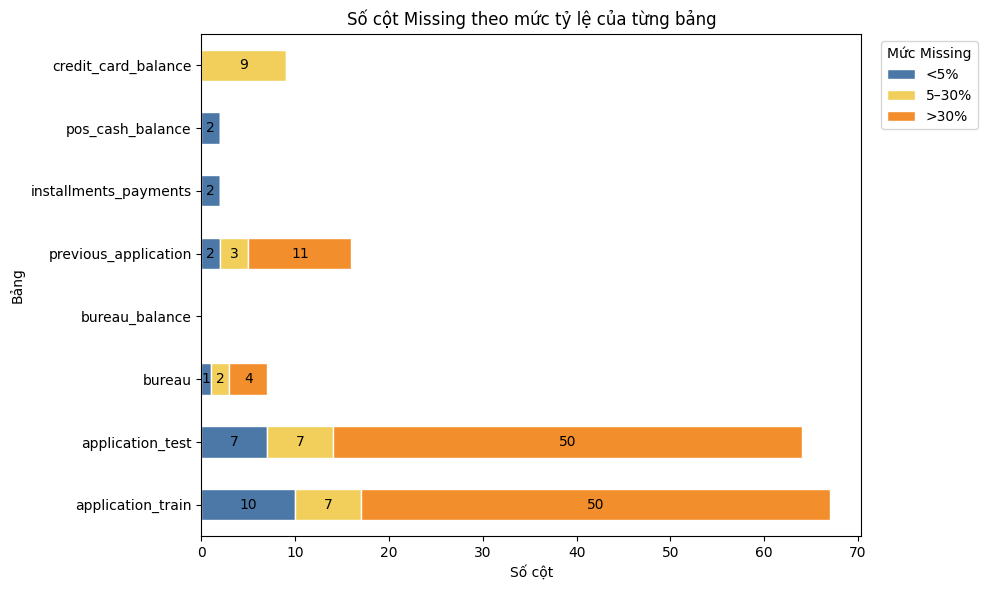

In [13]:
ax = missing_level_summary.plot(
    kind="barh", stacked=True, figsize=(10, 6),
    color=["#4C78A8", "#F2CF5B", "#F28E2B"], edgecolor="white",
)
ax.set(title="Số cột Missing theo mức tỷ lệ của từng bảng", xlabel="Số cột", ylabel="Bảng")
ax.legend(title="Mức Missing", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    labels = [f"{value:.0f}" if value > 0 else "" for value in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")
plt.tight_layout()
plt.show()

**Nhận xét:** application_train và application_test cùng có 50 cột thiếu trên 30%, cao hơn rõ rệt các bảng còn lại. previous_application có 11 cột thuộc nhóm này; bureau có 4. credit_card_balance chỉ có 9 cột ở mức 5–30%, còn Missing của installments_payments và pos_cash_balance đều dưới 5%. bureau_balance không có Missing.

Đoạn code bên dưới trực quan hóa 5 cột có tỷ lệ Missing cao nhất của từng bảng có Missing.

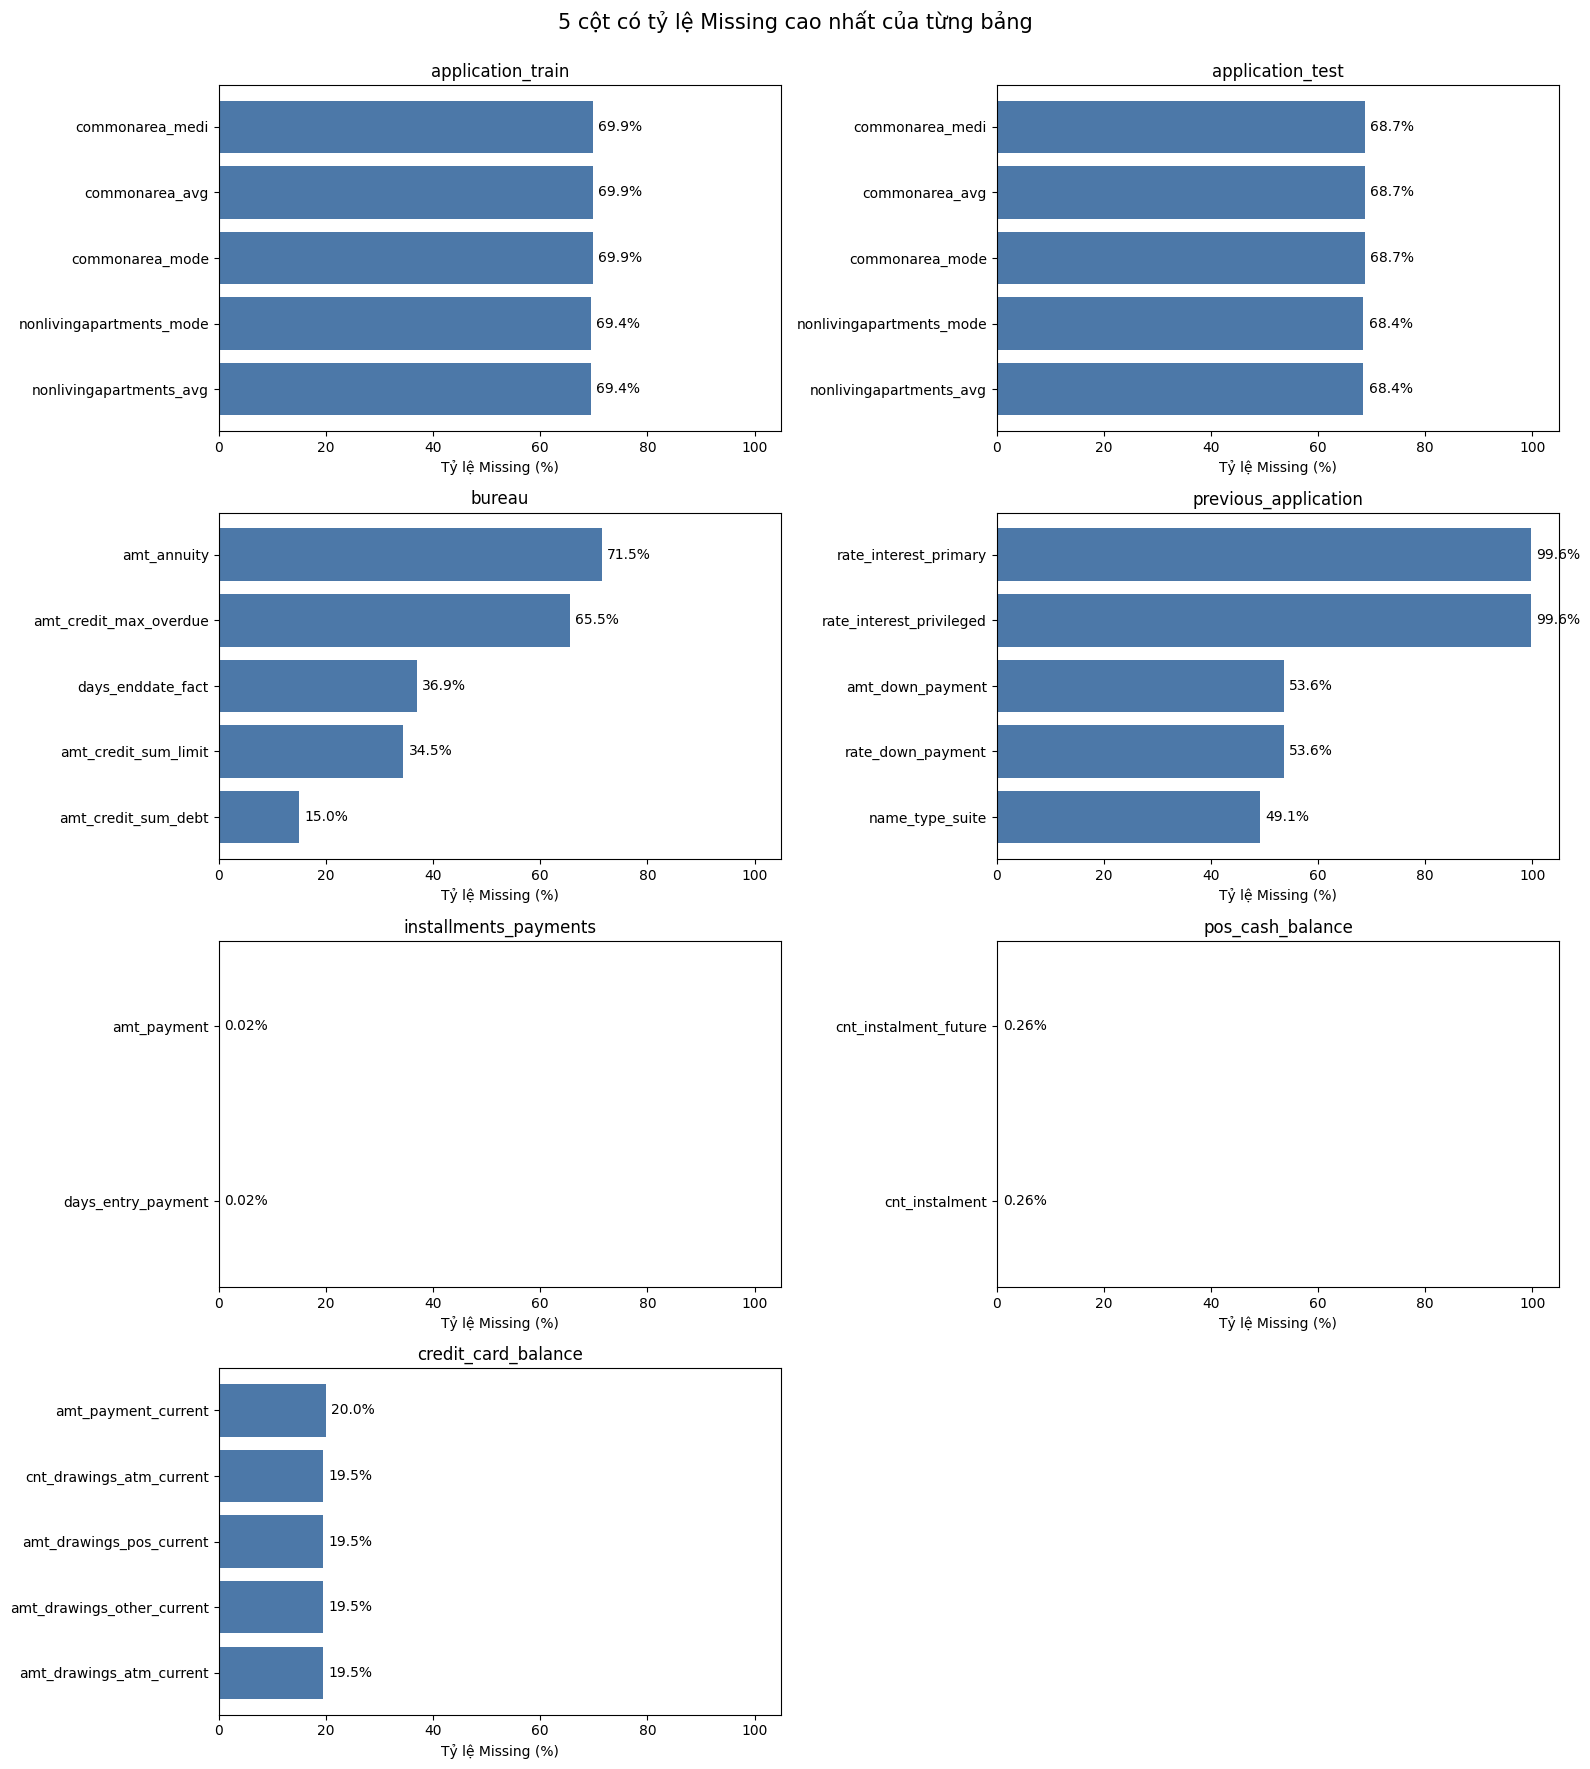

In [14]:
tables_with_missing = [table for table in raw_tables if table in top_missing_columns["Tên bảng"].unique()]
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for axis, table in zip(axes, tables_with_missing):
    chart_data = (top_missing_columns[top_missing_columns["Tên bảng"] == table]
                  .sort_values("Tỷ lệ missing (%)"))
    axis.barh(chart_data["Tên cột"], chart_data["Tỷ lệ missing (%)"], color="#4C78A8")
    axis.set(title=table, xlabel="Tỷ lệ Missing (%)", xlim=(0, 105))
    for index, value in enumerate(chart_data["Tỷ lệ missing (%)"]):
        label = f"{value:.2f}%" if value < 1 else f"{value:.1f}%"
        axis.text(value + 1, index, label, va="center")

for axis in axes[len(tables_with_missing):]:
    axis.axis("off")
fig.suptitle("5 cột có tỷ lệ Missing cao nhất của từng bảng", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

**Nhận xét:** Biểu đồ cho thấy Missing không có cùng mức độ giữa các bảng. Hai cột lãi suất của previous_application gần như trống hoàn toàn (99,6%); nhóm thông tin nhà ở của hai bảng application thiếu khoảng 68–70%; bureau.amt_annuity thiếu 71,5%. Ngược lại, hai cột thiếu của installments_payments và pos_cash_balance đều dưới 0,3%. Đây mới là bằng chứng về mức độ; quyết định giữ, điền hay loại cột sẽ được chốt sau khi xem thêm ý nghĩa nghiệp vụ ở Mục 3.1.c.

**c. Insight và Cleaning Rule**

Phần này kế thừa các insight từ NB01: Missing xuất hiện ở nhiều cột; `occupation_type` thiếu nhiều nhưng vẫn có ý nghĩa nghiệp vụ; `amt_credit_sum_debt` của `bureau` thiếu khoảng 15%; `cnt_payment` của `previous_application` thiếu khoảng 22,3%; và các `ext_source_*` cần được kiểm tra thêm trước khi đưa vào mô hình. NB01 mới ghi nhận vấn đề, chưa chọn cách xử lý.

NB02 bổ sung insight về Missing phát sinh sau `LEFT JOIN`: có 44.020 khách không có lịch sử `bureau`, 16.454 không có `previous_application`, 15.868 không có `installments_payments`, 18.067 không có `pos_cash_balance` và 220.606 khách (71,7%) không có `credit_card_balance`. Đây là trạng thái **không có lịch sử**, không phải lỗi mất dữ liệu. Các số liệu này được dùng làm baseline để kiểm chứng kết quả join mới; NB03 vẫn làm sạch từng bảng raw trước rồi mới aggregate và join.

Tại NB03, các phát hiện trên được **kiểm tra lại trên toàn bộ 8 bảng PostgreSQL**, đo tỷ lệ và trực quan hóa ở Mục 3.1.a–b. Cleaning Rule bên dưới vì vậy được chốt từ chuỗi bằng chứng: **NB01 phát hiện → NB02 bổ sung insight tích hợp → NB03 xác nhận → xem ý nghĩa cột → quyết định xử lý**. Missing được xử lý theo tỷ lệ thiếu và ý nghĩa nghiệp vụ, không dùng một quy tắc chung cho mọi cột.

| Bảng / nhóm cột | Bằng chứng và insight | Cleaning Rule | Lý do |
|---|---|---|---|
| `application_train`, `application_test` – cột phân loại | Một số thông tin như nghề nghiệp và đặc điểm nhà ở bị thiếu; `occupation_type` thiếu khoảng 31–32% | Điền `Unknown` và tạo cờ Missing cho nhóm có tỷ lệ thiếu cao | Không gán khách hàng vào một nhóm có thật khi chưa biết thông tin |
| Hai bảng `application` – cột số | Nhóm nhà ở thiếu khoảng 46–70%; `ext_source_1` thiếu 56,38% ở train và 42,12% ở test; các cột còn lại thiếu từ rất thấp đến trung bình | Điền median tính **chỉ từ train**, dùng lại median đó cho test; tạo cờ Missing cho cột thiếu từ 5% trở lên | Median ít bị ảnh hưởng bởi outlier; dùng thống kê train cho test tránh rò rỉ dữ liệu và giữ cùng quy tắc |
| `own_car_age` | Thiếu khoảng 66% và phần lớn có thể do khách hàng không sở hữu ô tô | Nếu `flag_own_car = 'N'` thì điền 0; trường hợp có ô tô nhưng thiếu tuổi xe thì điền median của nhóm có ô tô và tạo cờ | Phân biệt 'không có ô tô' với 'có ô tô nhưng thiếu thông tin' |
| `bureau` | `amt_annuity` thiếu 71,47%; `days_enddate_fact` thường trống khi khoản vay chưa kết thúc; nhiều cột tiền tệ thiếu 6–66% | Giữ Missing có ý nghĩa, tạo cờ hoặc số lượng giá trị hợp lệ; khi tổng hợp chỉ tính trên giá trị có dữ liệu | Điền 0 hay median có thể biến 'chưa kết thúc/chưa ghi nhận' thành một giá trị tài chính không có thật |
| `bureau_balance` | Không có Missing | Không xử lý | Dữ liệu đã đầy đủ theo kiểm tra ban đầu |
| `previous_application` – lãi suất | `rate_interest_primary` và `rate_interest_privileged` cùng thiếu 99,64% | Loại 2 cột | Gần như không còn thông tin để học và việc điền sẽ chủ yếu tạo dữ liệu giả |
| `previous_application` – ngày, tiền và kỳ hạn | Nhóm ngày thiếu 40,30%; tiền trả trước thiếu 53,64%; niên kim và số kỳ thiếu khoảng 22,29% | Giữ Missing có ý nghĩa; cột phân loại điền `Unknown`; khi tổng hợp thêm số bản ghi hợp lệ và chỉ tính trên giá trị có dữ liệu | Missing có thể gắn với trạng thái hồ sơ hoặc loại hợp đồng, không nên điền median đồng loạt |
| `installments_payments` | `days_entry_payment` và `amt_payment` cùng thiếu 0,021% | Giữ dòng; không tự coi là đã trả 0; loại Missing khỏi phép tính về ngày/số tiền thực trả và đếm số bản ghi thiếu | Tỷ lệ rất nhỏ nhưng điền 0 có thể biến 'không rõ' thành 'không thanh toán' |
| `pos_cash_balance` | Hai cột số kỳ thiếu khoảng 0,26% | Giữ dòng; tính chỉ số trên giá trị hợp lệ và lưu số bản ghi thiếu | Không đủ bằng chứng để coi số kỳ thiếu là 0 |
| `credit_card_balance` | Nhóm rút tiền thiếu 19,52%; `amt_payment_current` thiếu 20,00% | Chỉ điền 0 cho thành phần rút tiền khi tổng rút tiền của tháng bằng 0; trường hợp khác giữ Missing, tạo cờ và tổng hợp trên giá trị hợp lệ | Chỉ dùng 0 khi cột tổng chứng minh tháng đó không phát sinh rút tiền |
| Các nhóm summary sau join | NB02 chứng minh các cột summary bị `NULL` đúng bằng số khách không có lịch sử; riêng nhóm thẻ tín dụng thiếu 71,7% khách | Tạo cờ `has_*_history`; điền 0 cho biến đếm/tổng khi khách không có lịch sử, nhưng không điền median đồng loạt cho biến trung bình/tỷ lệ | Giữ được tín hiệu 'không có lịch sử' và tránh tạo ra hành vi tín dụng giả |

**Insight:** Missing mang thông tin về hành vi và trạng thái hợp đồng. Vì vậy, quy trình ưu tiên giữ dòng dữ liệu, dùng `Unknown` cho phân loại, median có kiểm soát cho bảng khách hàng, loại cột gần như rỗng và giữ cờ/số lượng Missing cho các bảng lịch sử. Sau xử lý, Missing còn lại có chủ đích và sẽ được kiểm tra riêng, thay vì ép toàn bộ dữ liệu về 0 Missing.

**d. Xử lý Missing Values theo từng bảng**

**d.1. Tạo 8 bảng cleaned làm vùng làm việc**

Đoạn code bên dưới tạo 8 bảng `*_cleaned` làm bản sao để xử lý, không thay đổi các bảng raw.

In [15]:
cleaned_tables = {table: f"{table}_cleaned" for table in raw_tables}
raw_row_counts = table_overview.set_index("Tên bảng")["Số dòng"].to_dict()
created_rows = []

with conn:
    with conn.cursor() as cursor:
        for raw_table, cleaned_table in cleaned_tables.items():
            # Chỉ tạo lại bảng cleaned, không tác động bảng raw
            cursor.execute(sql.SQL("DROP TABLE IF EXISTS {}").format(
                sql.Identifier(cleaned_table)
            ))
            cursor.execute(sql.SQL("CREATE TABLE {} AS TABLE {}").format(
                sql.Identifier(cleaned_table), sql.Identifier(raw_table)
            ))
            copied_rows = cursor.rowcount
            status = "OK" if copied_rows == raw_row_counts[raw_table] else "Kiểm tra"
            created_rows.append([raw_table, cleaned_table, copied_rows, status])

created_table_summary = pd.DataFrame(created_rows, columns=[
    "Bảng raw", "Bảng cleaned", "Số dòng đã sao chép", "Trạng thái"
])
display(created_table_summary)

,Bảng raw,Bảng cleaned,Số dòng đã sao chép,Trạng thái
0,application_train,application_train_cleaned,307511,OK
1,application_test,application_test_cleaned,48744,OK
2,bureau,bureau_cleaned,1716428,OK
3,bureau_balance,bureau_balance_cleaned,27299925,OK
4,previous_application,previous_application_cleaned,1670214,OK
5,installments_payments,installments_payments_cleaned,13605401,OK
6,pos_cash_balance,pos_cash_balance_cleaned,10001358,OK
7,credit_card_balance,credit_card_balance_cleaned,3840312,OK


**Nhận xét:** Tám bảng `*_cleaned` là vùng làm việc riêng cho NB03. Cột `Trạng thái` dùng số dòng raw đã kiểm tra ở Mục 2.2 để xác nhận quá trình sao chép; các bước xử lý Missing sẽ tiếp tục trên những bảng này.

**d.2. Xử lý hai bảng `application_train` và `application_test`**

Đoạn code bên dưới lấy danh sách cột cần xử lý từ kết quả kiểm tra Missing ở Mục 3.1.a.

In [16]:
application_profile = missing_profile[
    missing_profile["Tên bảng"].isin(["application_train", "application_test"])
    & (missing_profile["Số ô missing"] > 0)
]

categorical_missing_cols = sorted(application_profile.loc[
    application_profile["Data Type"] == "text", "Tên cột"
].unique())
numeric_missing_cols = sorted(application_profile.loc[
    application_profile["Data Type"] != "text", "Tên cột"
].unique())
flag_missing_cols = sorted(application_profile.groupby("Tên cột")["Tỷ lệ missing (%)"].max()
                           .loc[lambda rate: rate >= 5].index)

display(pd.DataFrame({
    "Nhóm xử lý": ["Phân loại → Unknown", "Số → median train", "Cột tạo cờ Missing"],
    "Số cột": [len(categorical_missing_cols), len(numeric_missing_cols), len(flag_missing_cols)],
}))

,Nhóm xử lý,Số cột
0,Phân loại → Unknown,6
1,Số → median train,61
2,Cột tạo cờ Missing,57


**Nhận xét:** Danh sách xử lý được tạo từ tỷ lệ Missing thực tế của cả train và test. Cờ Missing chỉ dành cho cột thiếu từ 5% trở lên để tránh sinh quá nhiều cột không cần thiết.

Đoạn code bên dưới tạo cờ trước khi điền giá trị để mô hình vẫn nhận biết dữ liệu ban đầu từng bị thiếu.

In [17]:
application_clean_tables = ["application_train_cleaned", "application_test_cleaned"]

with conn:
    with conn.cursor() as cursor:
        for table in application_clean_tables:
            for column in flag_missing_cols:
                flag_column = f"{column}_missing"
                cursor.execute(sql.SQL("ALTER TABLE {} ADD COLUMN IF NOT EXISTS {} SMALLINT").format(
                    sql.Identifier(table), sql.Identifier(flag_column)
                ))

            # Gom toàn bộ cờ vào một lần cập nhật để chỉ quét mỗi bảng một lần
            flag_assignments = sql.SQL(", ").join(
                sql.SQL("{} = CASE WHEN {} IS NULL THEN 1 ELSE 0 END").format(
                    sql.Identifier(f"{column}_missing"), sql.Identifier(column)
                ) for column in flag_missing_cols
            )
            cursor.execute(sql.SQL("UPDATE {} SET {}").format(
                sql.Identifier(table), flag_assignments
            ))

display(pd.DataFrame({
    "Bảng cleaned": application_clean_tables,
    "Số cờ Missing đã tạo": [len(flag_missing_cols)] * 2,
}))

,Bảng cleaned,Số cờ Missing đã tạo
0,application_train_cleaned,57
1,application_test_cleaned,57


**Nhận xét:** Cùng một bộ cờ được tạo cho train và test. Giá trị `1` nghĩa là cột gốc từng bị thiếu, còn `0` nghĩa là có dữ liệu ngay từ đầu.

Đoạn code bên dưới điền `Unknown` cho các cột phân loại bị thiếu.

In [18]:
category_updates = []

with conn:
    with conn.cursor() as cursor:
        for table in application_clean_tables:
            for column in categorical_missing_cols:
                cursor.execute(sql.SQL("UPDATE {} SET {} = 'Unknown' WHERE {} IS NULL").format(
                    sql.Identifier(table), sql.Identifier(column), sql.Identifier(column)
                ))
                category_updates.append([table, column, cursor.rowcount])

category_update_summary = (pd.DataFrame(category_updates, columns=[
    "Bảng cleaned", "Cột", "Số ô đã điền"
]).groupby("Bảng cleaned", as_index=False)["Số ô đã điền"].sum())
display(category_update_summary)

,Bảng cleaned,Số ô đã điền
0,application_test_cleaned,119034
1,application_train_cleaned,764371


**Nhận xét:** `Unknown` tạo một nhóm riêng cho thông tin chưa biết, thay vì gán khách hàng vào một nhóm nghề nghiệp hoặc nhà ở có thật.

Đoạn code bên dưới xử lý riêng `own_car_age` theo trạng thái sở hữu ô tô.

In [19]:
with conn.cursor() as cursor:
    cursor.execute(
        "SELECT PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY own_car_age) "
        "FROM application_train_cleaned WHERE flag_own_car = 'Y' AND own_car_age IS NOT NULL"
    )
    car_age_median = cursor.fetchone()[0]

car_age_updates = []
with conn:
    with conn.cursor() as cursor:
        for table in application_clean_tables:
            cursor.execute(sql.SQL(
                "UPDATE {} SET own_car_age = 0 WHERE flag_own_car = 'N' AND own_car_age IS NULL"
            ).format(sql.Identifier(table)))
            no_car_rows = cursor.rowcount
            cursor.execute(sql.SQL(
                "UPDATE {} SET own_car_age = %s WHERE own_car_age IS NULL"
            ).format(sql.Identifier(table)), (car_age_median,))
            car_missing_rows = cursor.rowcount
            car_age_updates.append([table, no_car_rows, car_missing_rows])

display(pd.DataFrame(car_age_updates, columns=[
    "Bảng cleaned", "Không có ô tô → 0", "Có ô tô nhưng thiếu → median"
]))

,Bảng cleaned,Không có ô tô → 0,Có ô tô nhưng thiếu → median
0,application_train_cleaned,202924,5
1,application_test_cleaned,32311,1


**Nhận xét:** Giá trị `0` chỉ biểu thị khách hàng không sở hữu ô tô. Median của nhóm có ô tô được lấy từ train và dùng lại cho test để giữ cùng một quy tắc.

Đoạn code bên dưới tính median các cột số từ train rồi dùng các giá trị đó để điền cho cả train và test.

In [20]:
numeric_impute_cols = [column for column in numeric_missing_cols if column != "own_car_age"]
median_columns_sql = sql.SQL(", ").join(
    sql.SQL("PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY {})").format(sql.Identifier(column))
    for column in numeric_impute_cols
)

with conn.cursor() as cursor:
    cursor.execute(sql.SQL("SELECT {} FROM application_train_cleaned").format(median_columns_sql))
    numeric_medians = dict(zip(numeric_impute_cols, cursor.fetchone()))

with conn:
    with conn.cursor() as cursor:
        for table in application_clean_tables:
            # Điền tất cả cột số trong một lần quét mỗi bảng
            numeric_assignments = sql.SQL(", ").join(
                sql.SQL("{} = COALESCE({}, %s)").format(
                    sql.Identifier(column), sql.Identifier(column)
                ) for column in numeric_impute_cols
            )
            missing_condition = sql.SQL(" OR ").join(
                sql.SQL("{} IS NULL").format(sql.Identifier(column))
                for column in numeric_impute_cols
            )
            cursor.execute(sql.SQL("UPDATE {} SET {} WHERE {}").format(
                sql.Identifier(table), numeric_assignments, missing_condition
            ), [numeric_medians[column] for column in numeric_impute_cols])

numeric_update_summary = (application_profile[
    application_profile["Tên cột"].isin(numeric_impute_cols)
].groupby("Tên bảng", as_index=False)["Số ô missing"].sum())
numeric_update_summary["Tên bảng"] += "_cleaned"
numeric_update_summary.columns = ["Bảng cleaned", "Số ô đã điền"]
display(numeric_update_summary)

,Bảng cleaned,Số ô đã điền
0,application_test_cleaned,1253073
1,application_train_cleaned,8185165


**Nhận xét:** Toàn bộ median đều được học từ `application_train_cleaned`; test không tự tính median nên tránh dùng thông tin của tập cần dự đoán. Các cờ Missing vẫn giữ lại trạng thái trước khi điền.

**d.3. Xử lý bảng `bureau`**

**Kiểm tra ý nghĩa Missing của `bureau`**

Đoạn code bên dưới so sánh tỷ lệ Missing theo trạng thái khoản tín dụng.

In [21]:
bureau_missing_cols = [
    "amt_annuity", "amt_credit_max_overdue", "days_enddate_fact",
    "amt_credit_sum_limit", "amt_credit_sum_debt",
    "days_credit_enddate", "amt_credit_sum",
]
missing_counts_sql = sql.SQL(", ").join(
    sql.SQL("COUNT(*) FILTER (WHERE {} IS NULL)").format(sql.Identifier(column))
    for column in bureau_missing_cols
)

with conn.cursor() as cursor:
    cursor.execute(sql.SQL(
        "SELECT credit_active, COUNT(*), {} FROM bureau "
        "GROUP BY credit_active ORDER BY COUNT(*) DESC"
    ).format(missing_counts_sql))
    bureau_status_wide = pd.DataFrame(cursor.fetchall(), columns=[
        "Trạng thái", "Tổng số dòng", *bureau_missing_cols
    ])

rate_columns = []
for column in bureau_missing_cols:
    rate_column = f"{column} (%)"
    bureau_status_wide[rate_column] = (
        bureau_status_wide[column] / bureau_status_wide["Tổng số dòng"] * 100
    ).round(2)
    rate_columns.append(rate_column)

display(bureau_status_wide[["Trạng thái", "Tổng số dòng", *rate_columns]])

,Trạng thái,Tổng số dòng,amt_annuity (%),amt_credit_max_overdue (%),days_enddate_fact (%),amt_credit_sum_limit (%),amt_credit_sum_debt (%),days_credit_enddate (%),amt_credit_sum (%)
0,Closed,1079273,73.26,65.53,0.01,38.32,16.73,3.00,0.0
1,Active,630607,68.43,65.36,99.69,27.48,11.66,11.50,0.0
2,Sold,6527,70.03,76.71,74.75,75.52,54.74,9.59,0.0
3,Bad debt,21,95.24,28.57,52.38,42.86,28.57,4.76,0.0


**Nhận xét:** `days_enddate_fact` thiếu 99,69% ở khoản vay `Active` nhưng chỉ 0,01% ở `Closed`, xác nhận đây chủ yếu là Missing có ý nghĩa vì khoản vay chưa kết thúc. Các cột tiền thiếu ở cả hai trạng thái; ví dụ `amt_credit_sum_debt` thiếu 11,66% ở `Active` và 16,73% ở `Closed`, nên Missing không đồng nghĩa số tiền bằng 0. Riêng `amt_credit_sum` chỉ thiếu 13 dòng nhưng vẫn không thể suy ra giá trị thật.

Đoạn code bên dưới tạo cờ cho 7 cột Missing của `bureau_cleaned` và giữ nguyên giá trị `NULL` ở cột gốc.

In [22]:
bureau_flag_columns = {
    column: f"{column}_missing" for column in bureau_missing_cols
}

with conn:
    with conn.cursor() as cursor:
        for flag_column in bureau_flag_columns.values():
            cursor.execute(sql.SQL(
                "ALTER TABLE bureau_cleaned ADD COLUMN IF NOT EXISTS {} SMALLINT"
            ).format(sql.Identifier(flag_column)))

        # Tạo toàn bộ cờ trong một lần quét bảng
        flag_assignments = sql.SQL(", ").join(
            sql.SQL("{} = COALESCE({}, CASE WHEN {} IS NULL THEN 1 ELSE 0 END)").format(
                sql.Identifier(flag), sql.Identifier(flag), sql.Identifier(column)
            ) for column, flag in bureau_flag_columns.items()
        )
        missing_flag_condition = sql.SQL(" OR ").join(
            sql.SQL("{} IS NULL").format(sql.Identifier(flag))
            for flag in bureau_flag_columns.values()
        )
        cursor.execute(sql.SQL("UPDATE bureau_cleaned SET {} WHERE {}").format(
            flag_assignments, missing_flag_condition
        ))

display(pd.DataFrame({
    "Cột gốc": bureau_flag_columns.keys(),
    "Cột cờ": bureau_flag_columns.values(),
}))

,Cột gốc,Cột cờ
0,amt_annuity,amt_annuity_missing
1,amt_credit_max_overdue,amt_credit_max_overdue_missing
2,days_enddate_fact,days_enddate_fact_missing
3,amt_credit_sum_limit,amt_credit_sum_limit_missing
4,amt_credit_sum_debt,amt_credit_sum_debt_missing
5,days_credit_enddate,days_credit_enddate_missing
6,amt_credit_sum,amt_credit_sum_missing


**Nhận xét:** Bảy cờ được lưu riêng trong `bureau_cleaned`; cột gốc không bị điền 0 hay median. Khi aggregate, tổng của mỗi cờ sẽ cho biết một khách hàng có bao nhiêu khoản tín dụng thiếu thông tin tương ứng.

Đoạn code bên dưới ghi nhận kết quả xử lý Missing của `bureau_cleaned`.

In [23]:
flag_checks_sql = []
for column, flag in bureau_flag_columns.items():
    flag_checks_sql.extend([
        sql.SQL("COUNT(*) FILTER (WHERE {} IS NULL)").format(sql.Identifier(column)),
        sql.SQL("SUM({})").format(sql.Identifier(flag)),
        sql.SQL("COUNT(*) FILTER (WHERE {} IS NULL OR {} NOT IN (0, 1))").format(
            sql.Identifier(flag), sql.Identifier(flag)
        ),
    ])

with conn.cursor() as cursor:
    cursor.execute(sql.SQL("SELECT {} FROM bureau_cleaned").format(
        sql.SQL(", ").join(flag_checks_sql)
    ))
    check_values = cursor.fetchone()

bureau_raw_missing = (raw_missing_baseline[
    raw_missing_baseline["Tên bảng"] == "bureau"
].set_index("Tên cột")["Số ô missing"])

bureau_result_rows = []
for index, (column, flag) in enumerate(bureau_flag_columns.items()):
    missing_count, flag_count, invalid_count = check_values[index * 3:index * 3 + 3]
    original_count = bureau_raw_missing[column]
    status = "OK" if original_count == missing_count == flag_count and invalid_count == 0 else "Kiểm tra"
    bureau_result_rows.append([
        column, original_count, missing_count, flag_count,
        0, "Giữ NULL + tạo cờ", status,
    ])

bureau_result_log = pd.DataFrame(bureau_result_rows, columns=[
    "Cột gốc", "Số Missing ban đầu", "Số Missing còn giữ", "Số cờ bằng 1",
    "Số ô đã điền", "Cách xử lý", "Kết quả",
])
display(bureau_result_log)

,Cột gốc,Số Missing ban đầu,Số Missing còn giữ,Số cờ bằng 1,Số ô đã điền,Cách xử lý,Kết quả
0,amt_annuity,1226791,1226791,1226791,0,Giữ NULL + tạo cờ,OK
1,amt_credit_max_overdue,1124488,1124488,1124488,0,Giữ NULL + tạo cờ,OK
2,days_enddate_fact,633653,633653,633653,0,Giữ NULL + tạo cờ,OK
3,amt_credit_sum_limit,591780,591780,591780,0,Giữ NULL + tạo cờ,OK
4,amt_credit_sum_debt,257669,257669,257669,0,Giữ NULL + tạo cờ,OK
5,days_credit_enddate,105553,105553,105553,0,Giữ NULL + tạo cờ,OK
6,amt_credit_sum,13,13,13,0,Giữ NULL + tạo cờ,OK


**Nhận xét:** `Số ô đã điền = 0` nghĩa là không thực hiện imputation, không phải điền số 0 vào cột gốc. Trạng thái `OK` xác nhận toàn bộ Missing ban đầu được giữ nguyên và được đánh dấu bằng cờ tương ứng.

**Cách sử dụng cờ `bureau` khi aggregate**

Các cờ chưa được aggregate tại đây. Khi gom `bureau_cleaned` về một dòng cho mỗi khách hàng ở Mục 4, mỗi cột Missing sẽ đi cùng thông tin về độ đầy đủ dữ liệu.

| Kết quả cần tạo | Cách tính trong PostgreSQL | Ý nghĩa |
|---|---|---|
| Giá trị tổng hợp | `SUM/AVG/MAX(cột_gốc)` | Chỉ tính trên những khoản có dữ liệu vì PostgreSQL bỏ qua `NULL` |
| Số khoản có dữ liệu | `COUNT(cột_gốc)` | Cho biết kết quả được tính từ bao nhiêu khoản tín dụng hợp lệ |
| Số khoản bị thiếu | `SUM(cờ_missing)` | Đếm số khoản thiếu thông tin của khách hàng |
| Tỷ lệ khoản bị thiếu | `AVG(cờ_missing)` | Đo mức độ thiếu từ 0 đến 1 của khách hàng |
| Số khoản đang hoạt động chưa kết thúc | Đếm dòng có `credit_active = 'Active'` và `days_enddate_fact_missing = 1` | Tách Missing có ý nghĩa trạng thái khỏi lỗi ghi nhận thông thường |

Ví dụ với `amt_annuity`, Mục 4 có thể tạo `bureau_amt_annuity_avg`, `bureau_amt_annuity_valid_count`, `bureau_amt_annuity_missing_count` và `bureau_amt_annuity_missing_rate`. Nhờ đó, mô hình không chỉ nhận giá trị niên kim trung bình mà còn biết giá trị đó được tính từ mức độ đầy đủ dữ liệu nào.

**Kết luận:** Phần Missing của `bureau` đã hoàn tất ở mức bảng cleaned: không tạo dữ liệu tài chính giả, giữ Missing có ý nghĩa và lưu đủ cờ để aggregate sau.

**d.4. Xử lý bảng `bureau_balance`**

**d.5. Xử lý bảng `previous_application`**

Đoạn code bên dưới kiểm tra tỷ lệ Missing theo trạng thái hồ sơ vay trước.

In [24]:
previous_check_cols = [
    "rate_interest_primary", "days_first_drawing", "amt_down_payment",
    "name_type_suite", "amt_annuity", "cnt_payment", "product_combination",
]
previous_counts_sql = sql.SQL(", ").join(
    sql.SQL("COUNT(*) FILTER (WHERE {} IS NULL)").format(sql.Identifier(column))
    for column in previous_check_cols
)

with conn.cursor() as cursor:
    cursor.execute(sql.SQL(
        "SELECT name_contract_status, COUNT(*), {} FROM previous_application "
        "GROUP BY name_contract_status ORDER BY COUNT(*) DESC"
    ).format(previous_counts_sql))
    previous_status = pd.DataFrame(cursor.fetchall(), columns=[
        "Trạng thái", "Tổng số dòng", *previous_check_cols
    ])

previous_rate_cols = []
for column in previous_check_cols:
    rate_column = f"{column} (%)"
    previous_status[rate_column] = (
        previous_status[column] / previous_status["Tổng số dòng"] * 100
    ).round(2)
    previous_rate_cols.append(rate_column)

display(previous_status[["Trạng thái", "Tổng số dòng", *previous_rate_cols]])

,Trạng thái,Tổng số dòng,rate_interest_primary (%),days_first_drawing (%),amt_down_payment (%),name_type_suite (%),amt_annuity (%),cnt_payment (%),product_combination (%)
0,Approved,1036781,99.43,3.82,36.11,35.92,0.00,0.00,0.00
1,Canceled,316319,100.00,100.00,99.80,96.84,96.68,96.68,0.10
2,Refused,290678,100.00,100.00,69.95,41.55,14.07,14.07,0.01
3,Unused offer,26436,100.00,100.00,9.24,78.82,96.55,96.55,0.00


**Nhận xét:** Nhóm ngày thiếu 100% ở hồ sơ `Canceled`, `Refused` và `Unused offer`, nhưng `days_first_drawing` chỉ thiếu 3,82% ở `Approved`, cho thấy Missing chủ yếu gắn với hồ sơ chưa phát sinh hợp đồng. `amt_annuity` và `cnt_payment` đầy đủ ở `Approved` nhưng thiếu khoảng 96,6% ở `Canceled/Unused offer`, nên không được điền median hay 0. Hai cột lãi suất thiếu 99,43–100% ở mọi trạng thái, gần như không còn thông tin để sử dụng.

Đoạn code bên dưới loại 2 cột lãi suất, điền `Unknown` cho cột phân loại và tạo cờ cho các Missing còn lại.

In [25]:
previous_missing_cols = list(raw_missing_baseline.loc[
    (raw_missing_baseline["Tên bảng"] == "previous_application")
    & (raw_missing_baseline["Số ô missing"] > 0), "Tên cột"
])
previous_drop_cols = ["rate_interest_primary", "rate_interest_privileged"]
previous_category_cols = ["name_type_suite", "product_combination"]
previous_flag_cols = [
    column for column in previous_missing_cols if column not in previous_drop_cols
]
previous_flag_columns = {column: f"{column}_missing" for column in previous_flag_cols}

with conn:
    with conn.cursor() as cursor:
        for flag in previous_flag_columns.values():
            cursor.execute(sql.SQL(
                "ALTER TABLE previous_application_cleaned ADD COLUMN IF NOT EXISTS {} SMALLINT"
            ).format(sql.Identifier(flag)))

        # Tạo toàn bộ cờ trước khi điền Unknown
        flag_assignments = sql.SQL(", ").join(
            sql.SQL("{} = CASE WHEN {} IS NULL THEN 1 ELSE 0 END").format(
                sql.Identifier(flag), sql.Identifier(column)
            ) for column, flag in previous_flag_columns.items()
        )
        cursor.execute(sql.SQL("UPDATE previous_application_cleaned SET {}").format(
            flag_assignments
        ))

        cursor.execute(
            "UPDATE previous_application_cleaned SET "
            "name_type_suite = COALESCE(name_type_suite, 'Unknown'), "
            "product_combination = COALESCE(product_combination, 'Unknown') "
            "WHERE name_type_suite IS NULL OR product_combination IS NULL"
        )
        for column in previous_drop_cols:
            cursor.execute(sql.SQL(
                "ALTER TABLE previous_application_cleaned DROP COLUMN IF EXISTS {}"
            ).format(sql.Identifier(column)))

display(pd.DataFrame({
    "Cách xử lý": ["Loại cột", "Điền Unknown + tạo cờ", "Giữ NULL + tạo cờ"],
    "Số cột": [2, 2, len(previous_flag_cols) - 2],
}))

,Cách xử lý,Số cột
0,Loại cột,2
1,Điền Unknown + tạo cờ,2
2,Giữ NULL + tạo cờ,12


**Nhận xét:** Chỉ hai cột gần như rỗng bị loại. Missing phân loại được chuyển thành `Unknown`; các cột ngày, tiền và kỳ hạn vẫn giữ `NULL` có ý nghĩa cùng cờ tương ứng.

Đoạn code bên dưới ghi nhận và kiểm tra kết quả xử lý của `previous_application_cleaned`.

In [26]:
previous_checks_sql = []
for column, flag in previous_flag_columns.items():
    previous_checks_sql.extend([
        sql.SQL("COUNT(*) FILTER (WHERE {} IS NULL)").format(sql.Identifier(column)),
        sql.SQL("SUM({})").format(sql.Identifier(flag)),
        sql.SQL("COUNT(*) FILTER (WHERE {} IS NULL OR {} NOT IN (0, 1))").format(
            sql.Identifier(flag), sql.Identifier(flag)
        ),
    ])

with conn.cursor() as cursor:
    cursor.execute(sql.SQL("SELECT {} FROM previous_application_cleaned").format(
        sql.SQL(", ").join(previous_checks_sql)
    ))
    previous_check_values = cursor.fetchone()
    cursor.execute(
        "SELECT column_name FROM information_schema.columns "
        "WHERE table_schema = 'public' AND table_name = 'previous_application_cleaned'"
    )
    previous_existing_cols = {row[0] for row in cursor.fetchall()}

previous_raw_missing = (raw_missing_baseline[
    raw_missing_baseline["Tên bảng"] == "previous_application"
].set_index("Tên cột")["Số ô missing"])
previous_check_map = {
    column: previous_check_values[index * 3:index * 3 + 3]
    for index, column in enumerate(previous_flag_cols)
}

previous_result_rows = []
for column in previous_missing_cols:
    original_count = int(previous_raw_missing[column])
    if column in previous_drop_cols:
        status = "OK" if column not in previous_existing_cols else "Kiểm tra"
        previous_result_rows.append([column, original_count, "Đã loại", "-", 0, "Loại cột", status])
        continue

    missing_count, flag_count, invalid_count = previous_check_map[column]
    if column in previous_category_cols:
        action = "Unknown + cờ"
        valid = missing_count == 0 and flag_count == original_count
    else:
        action = "Giữ NULL + cờ"
        valid = missing_count == flag_count == original_count
    status = "OK" if valid and invalid_count == 0 else "Kiểm tra"
    previous_result_rows.append([
        column, original_count, missing_count, flag_count,
        original_count - missing_count, action, status,
    ])

previous_result_log = pd.DataFrame(previous_result_rows, columns=[
    "Cột gốc", "Missing ban đầu", "Missing còn lại", "Số cờ bằng 1",
    "Số ô đã điền", "Cách xử lý", "Kết quả",
])
display(previous_result_log)

,Cột gốc,Missing ban đầu,Missing còn lại,Số cờ bằng 1,Số ô đã điền,Cách xử lý,Kết quả
0,amt_annuity,372235,372235,372235,0,Giữ NULL + cờ,OK
1,amt_credit,1,1,1,0,Giữ NULL + cờ,OK
2,amt_down_payment,895844,895844,895844,0,Giữ NULL + cờ,OK
3,amt_goods_price,385515,385515,385515,0,Giữ NULL + cờ,OK
4,rate_down_payment,895844,895844,895844,0,Giữ NULL + cờ,OK
5,rate_interest_primary,1664263,Đã loại,-,0,Loại cột,OK
6,rate_interest_privileged,1664263,Đã loại,-,0,Loại cột,OK
7,name_type_suite,820405,0,820405,820405,Unknown + cờ,OK
8,cnt_payment,372230,372230,372230,0,Giữ NULL + cờ,OK
9,product_combination,346,0,346,346,Unknown + cờ,OK


**Nhận xét:** Bảng kết quả đồng thời kiểm tra đủ ba quy tắc: 2 cột lãi suất đã bị loại; 2 cột phân loại không còn `NULL` nhưng vẫn giữ cờ; 12 cột còn lại giữ nguyên Missing và có số cờ bằng `1` khớp baseline. Khi aggregate ở Mục 4, các giá trị hợp lệ sẽ đi cùng `COUNT(cột)`, `SUM(cờ)` và `AVG(cờ)`.

**d.6. Xử lý bảng `installments_payments`**

**d.7. Xử lý bảng `pos_cash_balance`**

**d.8. Xử lý bảng `credit_card_balance`**

**e. Kiểm tra Missing Values sau xử lý**

**e.1. Đối chiếu số dòng và khóa của 8 bảng cleaned**

**e.2. Kiểm tra lại Missing, giá trị đã điền và cờ Missing**

**e.3. Lập bảng Before và After theo từng bảng**

**e.4. Trực quan hóa kết quả sau xử lý**

**e.5. Kết luận về Missing Values**

### 3.2. Xử lý Duplicate

**a. Xác định tiêu chí Duplicate theo grain và khóa của từng bảng**

**b. Kiểm tra dòng trùng hoàn toàn và khóa trùng của 8 bảng cleaned**

**c. Xử lý Duplicate theo từng bảng**

**d. Kiểm tra số bản ghi bị loại và grain sau xử lý**

### 3.3. Xử lý Outlier

**a. Chọn cột kiểm tra và giải thích lý do lựa chọn**

**b. Nhận diện Outlier bằng IQR và thống kê mô tả**

**c. Trực quan hóa trước xử lý**

**d. Rút ra insight và chốt Cleaning Rule**

**e. Xử lý Outlier theo từng nhóm cột**

**f. Kiểm tra và trực quan hóa sau xử lý**

### 3.4. Xử lý dữ liệu sai logic

**a. Xây dựng quy tắc logic theo ý nghĩa nghiệp vụ**

**b. Kiểm tra và xử lý hai bảng application**

**c. Kiểm tra và xử lý `bureau` và `bureau_balance`**

**d. Kiểm tra và xử lý `previous_application`**

**e. Kiểm tra và xử lý ba bảng giao dịch**

**f. Kiểm tra số giá trị bất thường trước và sau xử lý**

### 3.5. Chuẩn hóa Data Type và rà soát cột không cần thiết

**a. Kiểm tra Data Type của 8 bảng cleaned**

**b. Chuẩn hóa kiểu dữ liệu theo nhóm Numeric, Category, Date và ID**

**c. Kiểm tra Constant Column, Duplicate Column, Unique Ratio và Missing lớn**

**d. Chốt danh sách cột giữ lại hoặc loại bỏ**

**e. Kiểm tra Data Type và số cột sau xử lý**

## 4. Tổng hợp và Join lại dữ liệu

### 4.1. Chốt grain và Cleaning Rule cho các bảng summary

### 4.2. Tạo `bureau_cleaned_summary` qua `bureau_balance_cleaned`

### 4.3. Tạo `previous_application_cleaned_summary`

### 4.4. Tạo `installments_payments_cleaned_summary`

### 4.5. Tạo `pos_cash_balance_cleaned_summary`

### 4.6. Tạo `credit_card_balance_cleaned_summary`

### 4.7. Kiểm tra grain và khóa của các bảng summary

### 4.8. Join tạo bảng flat cleaned cho train và test

### 4.9. Xử lý Missing Values phát sinh sau Join

### 4.10. Kiểm tra mất dữ liệu và tính nhất quán sau Join

## 5. Đánh giá sau Cleaning

### 5.1. Kiểm tra Shape

### 5.2. Kiểm tra Missing

### 5.3. Kiểm tra Duplicate

### 5.4. Kiểm tra Data Type

### 5.5. Kiểm tra Memory Usage

### 5.6. Bảng tổng hợp Before và After

### 5.7. Kết luận dữ liệu đã sẵn sàng cho EDA

## 6. Lưu dữ liệu vào PostgreSQL

### 6.1. Lưu 8 bảng cleaned

### 6.2. Lưu 5 bảng cleaned summary

### 6.3. Lưu bảng flat cleaned cho train và test

### 6.4. Đọc lại và kiểm tra dữ liệu sau khi lưu

## 7. Tổng kết

### 7.1. Kết quả làm sạch và tích hợp dữ liệu

### 7.2. Hạn chế còn lại và bàn giao sang Notebook 04